In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Load Data

Loading data from csv file and creating a copy.

In [2]:
df_raw = pd.read_csv('Data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df = df_raw.copy()

# 2. Dataset overview & Summary Statistics

Perform an initial inspection of the dataset's structure, data types, and generate descriptive statiscs for numeric, categorical and binary.

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**Insigths:**

Column `TotalCharges` has wrong type I will change it to `float`.

In [5]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [7]:
df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


In [8]:
df.shape

(7043, 21)

# 3. Automated Data Quality Audit

Design a custom Python class DataQualityCheck to systematically identyfy missig and duplicated values.

In [9]:
class DataQualityCheck:
    def __init__(self,dataframe):
        self.df = dataframe
    def check_missing_values(self):
        missing_values_pct = (self.df.isnull().sum() / len(self.df)) * 100
        return missing_values_pct[missing_values_pct > 0].sort_values(ascending=False).round(2)
    def check_duplicates(self):
        duplicated = self.df.duplicated().sum()
        return f"Sum of duplicated records in dataset: {duplicated}"

In [10]:
check_df = DataQualityCheck(df)
check_df.check_missing_values()

TotalCharges    0.16
dtype: float64

In [11]:
df[df.isnull().any(axis=1)]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


**Insights:**

Missing data in the `TotalCharges` column are not errors. All 11 affected customers have a `tenure of 0`, meaning they are new customers.

**Conculusion**

I will fill these missing values with 0.

In [12]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [13]:
check_df.check_missing_values()

Series([], dtype: float64)

**Insights**

All data imputed.

In [14]:
check_df.check_duplicates()

'Sum of duplicated records in dataset: 0'

**Insights:**

We found no duplicated records in this dataset.

# 4. Exploratory Data Analysis

## 4.1 Data Preprocessing

**Target Variable Encoding:** Mapping the Churn column to binary values to enable numerical analysis.

In [15]:
churn_map = {'Yes': 1,
             'No' : 0
            }
df['Churn'] = df['Churn'].map(churn_map)

## 4.2 Data Visualizer

Design a custom Python class DataVisualizer to create graphs.

In [16]:
class DataVisualizer:
    def __init__(self,dataframe):
        self.df = dataframe
    def histplots(self, columns,sup_title,n,m):
        sns.set_style('whitegrid')
        fig, axes = plt.subplots(nrows=n, ncols=m, figsize=(15,10), squeeze=False)
        fig.suptitle(sup_title)
        axes = axes.flatten()
        for i, (col) in enumerate(columns):
            sns.histplot(self.df[col], kde=True, bins=30, ax=axes[i])
            axes[i].set_title(f"Distribution of {col}")
            axes[i].set_xlabel(col)
            axes[i].set_ylabel('Count')
        for j in range(i + 1, m*n):
            axes[j].set_visible(False)
        plt.tight_layout()
        plt.show()
    def violinplots(self, columns,y_col,sup_title,n,m):
        sns.set_style('whitegrid')
        fig, axes = plt.subplots(nrows=n, ncols=m, figsize=(15,10))
        fig.suptitle(sup_title)
        axes = axes.flatten()
        for i, col in enumerate(columns):
            sns.violinplot(data = self.df, x = y_col, y = col, ax=axes[i])
            axes[i].set_title(f'{y_col} vs {col}')
            axes[i].set_xlabel(y_col)
            axes[i].set_ylabel(col)
        for j in range(i + 1, n*m):
            axes[j].set_visible(False)
        plt.tight_layout()
        plt.show()
    def countplots(self,columns):
        for i, col in enumerate(columns):
            sns.countplot(data=self.df, x=col, order=self.df[col].value_counts().index, hue=col,palette='viridis',legend=False)
            plt.title(f'Number of {col}')
            plt.xlabel(col)
            plt.ylabel('Count')
            plt.xticks(rotation=45)
            plt.show()
    def countplots_churn(self,columns, hue_col):
        for i, col in enumerate(columns):
            sns.countplot(data=self.df, x=col, order=self.df[col].value_counts().index, hue=hue_col,palette='viridis',legend=True)
            plt.title(f'Churn vs {col}')
            plt.xlabel(col)
            plt.ylabel('Count')
            plt.xticks(rotation=45)
            plt.show()
    def heatmap(self):
        numeric_cols = self.df.select_dtypes(include='number')
        correlations = numeric_cols.corr()
        plt.figure(figsize=(12,10))
        sns.heatmap(correlations, cmap='inferno', annot=True, fmt='.2f', square=True)
        plt.show()
        

## 4.2 Univariate Analysis

### 4.2.1 Continous Variables

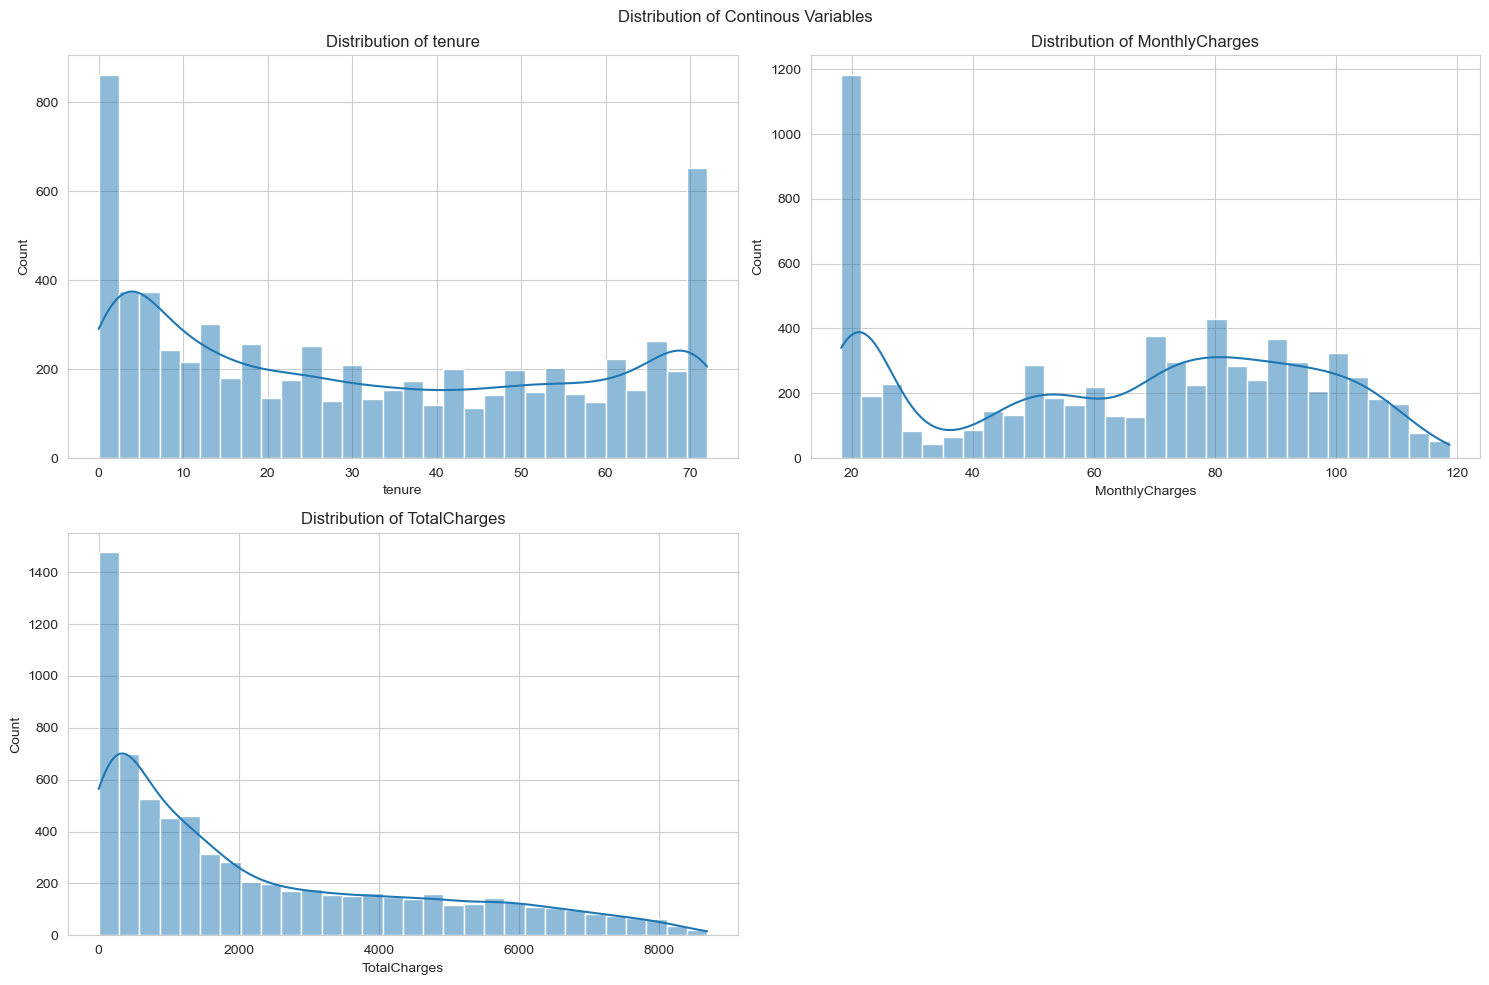

In [17]:
continous_variables = df[['tenure','MonthlyCharges','TotalCharges']]
viz_continous = DataVisualizer(df)
viz_continous.histplots(continous_variables,'Distribution of Continous Variables',2,2)

**Insights:**
* **Tenure:** The distribution of tenure is bimodal with two distinct peaks. This shows we have two large customer segments: a massive cohort of brand new clients (1-2 months) and a highly loyal group of long-term customers (68-74 months).
* **MonthlyCharges:** This distribution is also bimodal. The first peak represents clients paying the absolute minimum (around 20 USD), while the second peak (around 80 USD) represents clients paying for additional services and bundles (e.g., StreamingTV, DeviceProtection, Fiber Optic).

### 4.2.2 Categorical Variables

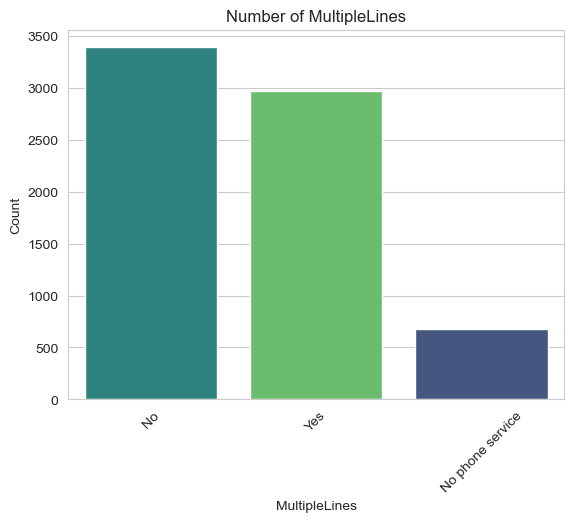

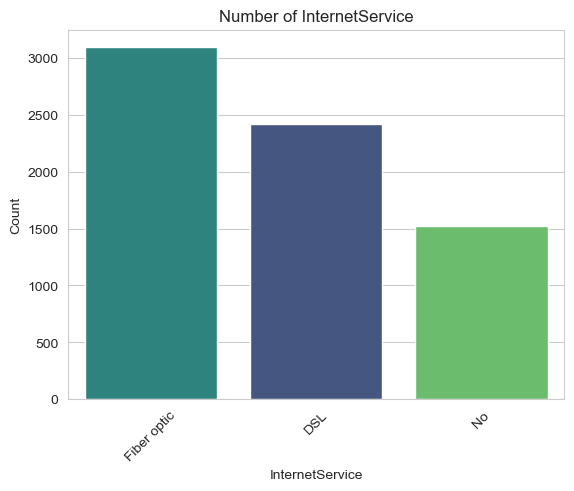

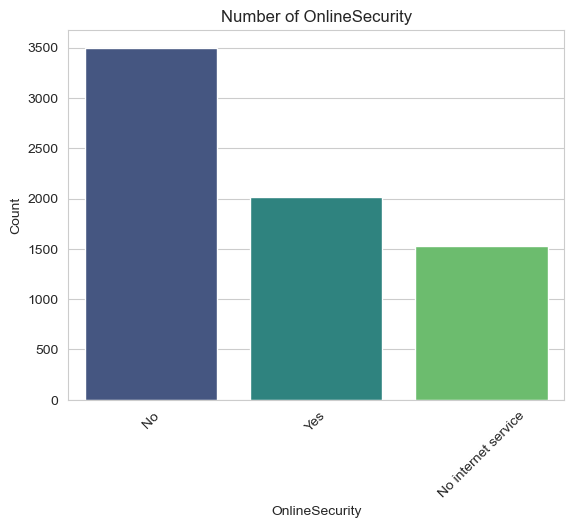

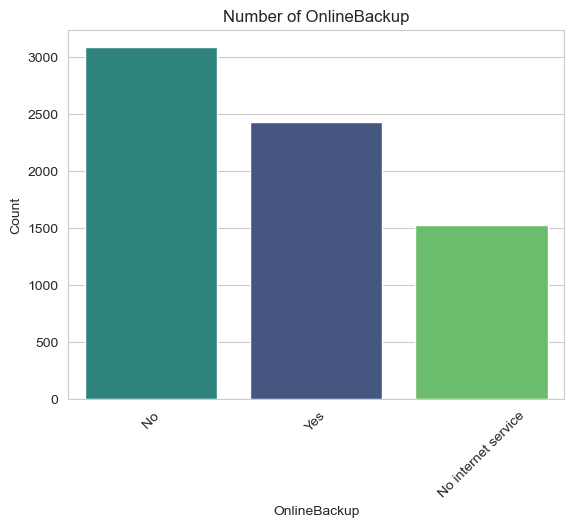

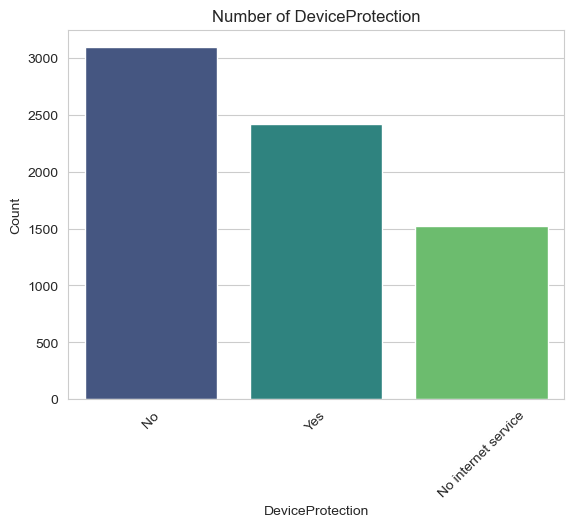

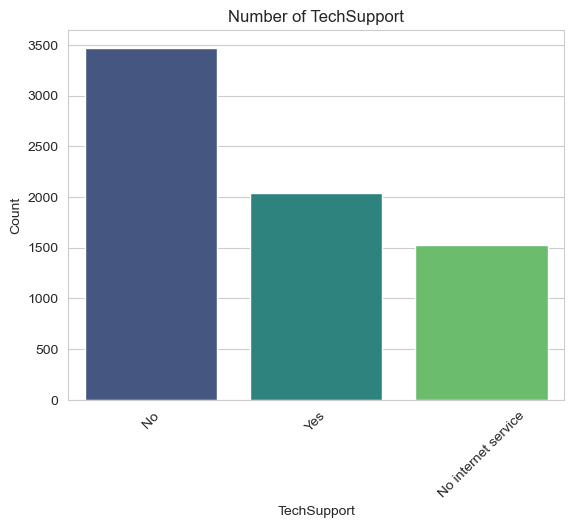

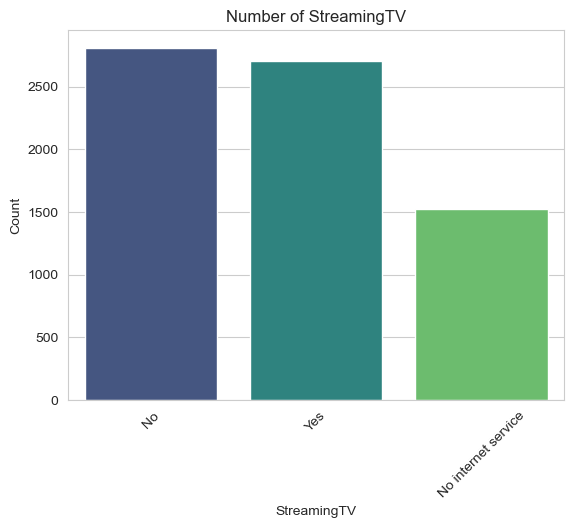

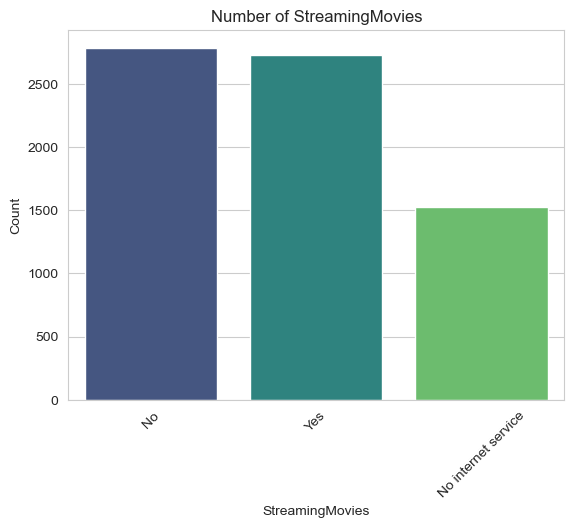

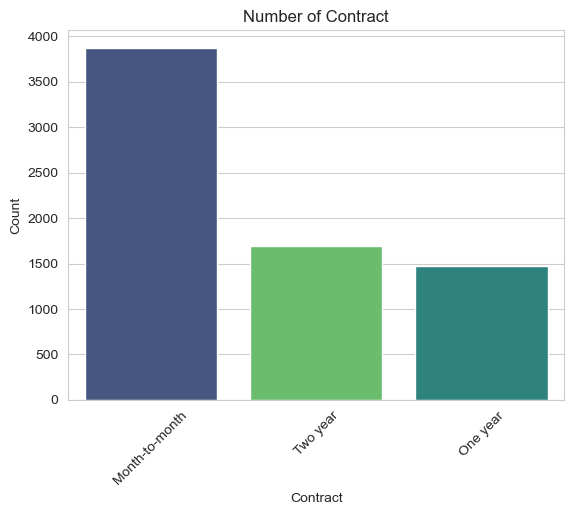

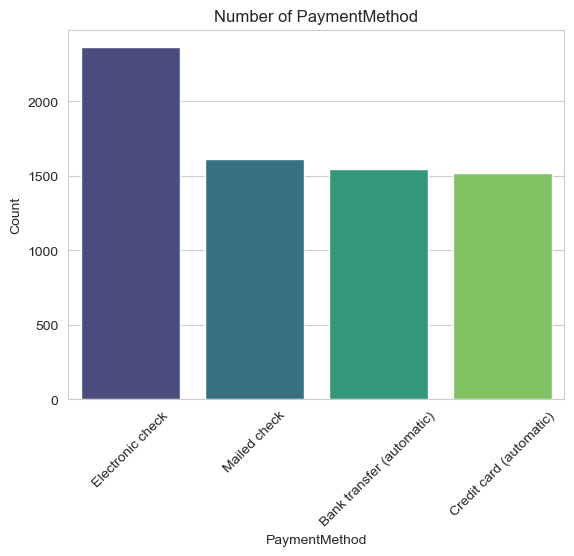

In [18]:
categorical_variables = df[['MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies',
                            'Contract','PaymentMethod']]
viz_categorical = DataVisualizer(df)
viz_categorical.countplots(categorical_variables)

In [19]:
for col in categorical_variables.columns:
    print(f'----{col}-----')
    print(f'{df[col].value_counts().sort_values(ascending=False)}')
    print('--------------')
    

----MultipleLines-----
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
--------------
----InternetService-----
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
--------------
----OnlineSecurity-----
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64
--------------
----OnlineBackup-----
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64
--------------
----DeviceProtection-----
DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64
--------------
----TechSupport-----
TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64
--------------
----StreamingTV-----
StreamingTV
No                    

**Insights:**
* **Add-on Services:** Most clients do not use additional services such as Multiple Lines, Online Security, Online Backup, Device Protection, and Tech Support (either by choice or because they do not have an internet subscription). Meanwhile, the adoption of StreamingTV and StreamingMovies is almost equally distributed.
* **Internet Service:** The most popular internet connection type among the customer base is Fiber Optic.
* **Contract Type:** About 50% of all clients are on Month-to-Month contracts. The remaining customers are almost equally split between longer-term commitments (Two-year: 1695 vs. One-year: 1473).
* **Payment Method:** When looking at individual methods, Electronic Check is by far the most popular (2365 clients), while Mailed Check (1612) slightly outpaces individual automatic methods. However, when grouped together, automatic payments (Bank transfer and Credit Card) form the largest segment overall with over 3000 users.

### 4.2.3 Binary Variables

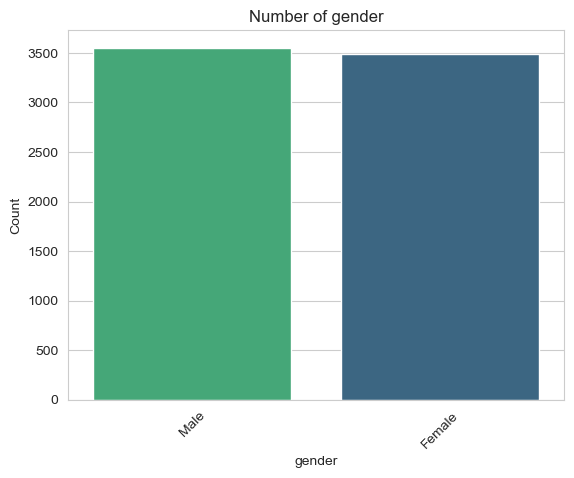

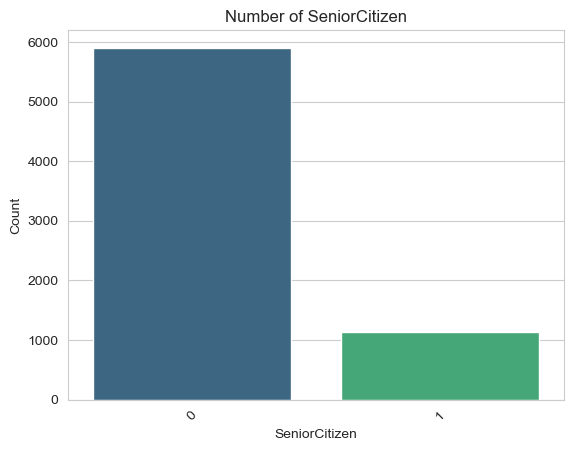

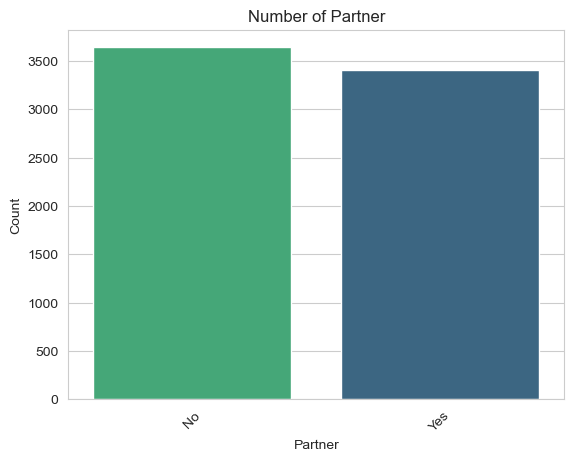

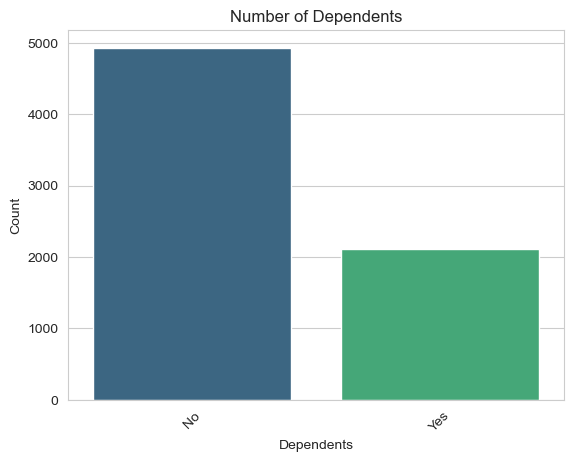

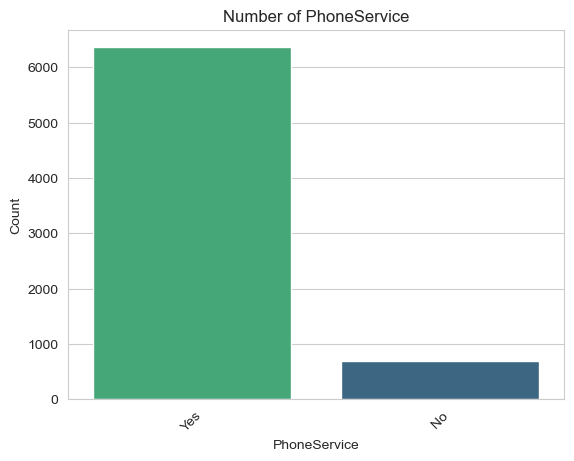

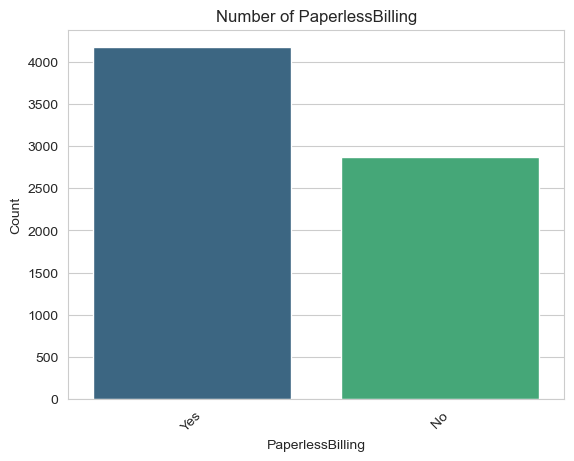

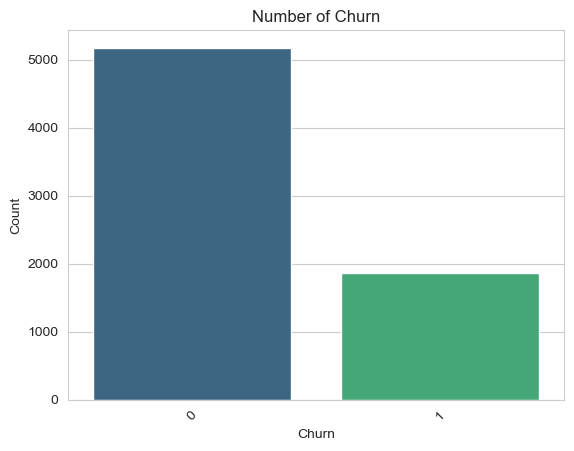

In [20]:
binary_variables = df[['gender', 'SeniorCitizen','Partner','Dependents','PhoneService','PaperlessBilling','Churn']]
viz_binary = DataVisualizer(df)
viz_binary.countplots(binary_variables)

In [21]:
for col in binary_variables.columns:
    print(f'----{col}-----')
    print(f'{df[col].value_counts().sort_values(ascending=False)}')
    print('--------------')
    

----gender-----
gender
Male      3555
Female    3488
Name: count, dtype: int64
--------------
----SeniorCitizen-----
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64
--------------
----Partner-----
Partner
No     3641
Yes    3402
Name: count, dtype: int64
--------------
----Dependents-----
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
--------------
----PhoneService-----
PhoneService
Yes    6361
No      682
Name: count, dtype: int64
--------------
----PaperlessBilling-----
PaperlessBilling
Yes    4171
No     2872
Name: count, dtype: int64
--------------
----Churn-----
Churn
0    5174
1    1869
Name: count, dtype: int64
--------------


**Demographics & Account Insights:**
* **Gender:** The customer base is almost equally distributed, with a very marginal majority of males.
* **SeniorCitizen:** Senior citizens represent a small minority of the customer base (only about 16%).
* **Partner & Dependents:** More than 50% of the customers do not have a partner. Furthermore, about 70% of customers do not have dependents, suggesting a predominantly independent or single customer base.
* **PhoneService:** The vast majority of customers (about 90%) subscribe to Phone Service.
* **PaperlessBilling:** Customers prefer Paperless Billing over traditional paper billing (roughly 60% vs. 40%).
* **Churn:** The overall churn rate is approximately 26.5% (meaning ~73.5% of customers stay while ~26.5% resign). This indicates an imbalanced target variable, which is crucial to remember for future machine learning models.

## 4.3 Correlations

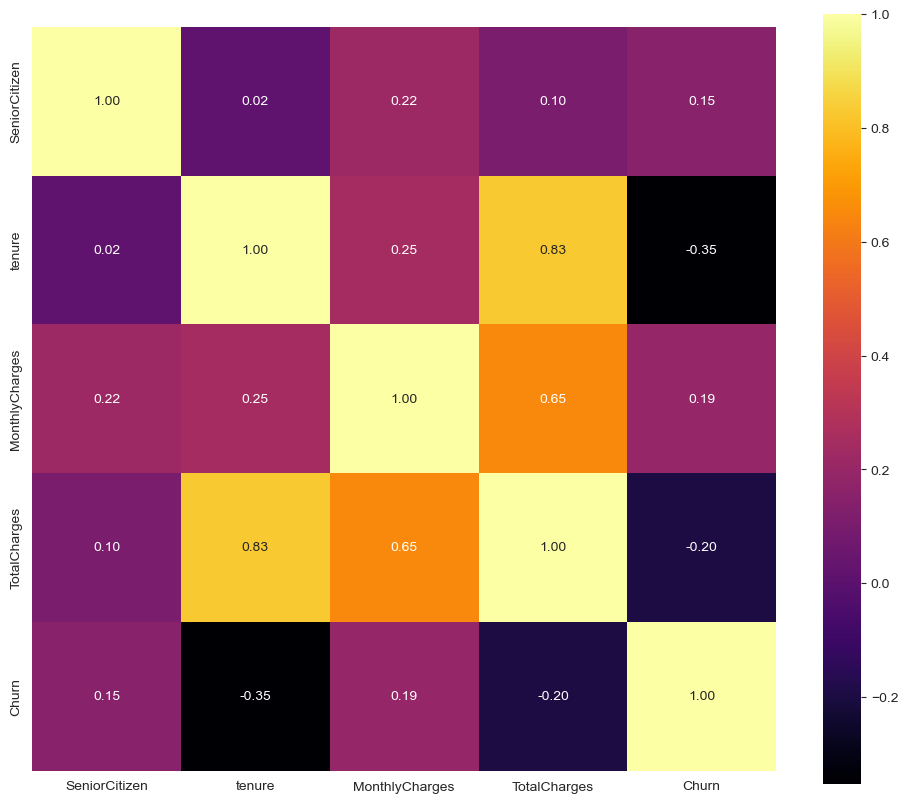

In [22]:
corr_viz = DataVisualizer(df)
corr_viz.heatmap()

**Numerical Correlations with Churn**
* **Negative Correlations:** Churn is negatively correlated with **tenure (r = -0.35)** and **TotalCharges (r = -0.20)**. This indicates that long-term customers and those who have generated higher cumulative revenue are significantly less likely to leave.
* **Positive Correlations:** A positive correlation exists with **MonthlyCharges (r = 0.19)** and **SeniorCitizen (r = 0.15)**. This suggests that customers with higher monthly bills and senior citizens tend to churn more frequently, pointing to price sensitivity or specific demographic needs that may not be fully met.

**Multicollinearity Insight:**

A very strong positive correlation exists between tenure and TotalCharges (r = 0.83). This is logically expected, as TotalCharges is the cumulative sum of bills over the duration of the customer's stay. From a modeling perspective, this high correlation suggests we should be mindful of multicollinearity.